# Figure4

In [1]:
import scipy
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rcParamsDefault
from typing import List, Union
import pandas as pd 
import numpy as np
from matplotlib.colors import Normalize, ListedColormap,LinearSegmentedColormap

eid = "E003"


EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


In [2]:
rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 8 ,
        'axes.titleweight' :'bold',
        'axes.titlesize': 10,  # Title font size
        
        'figure.titleweight' : 'bold' ,
        'figure.titlesize' : 8 ,
        
        'axes.labelsize' : 8 ,
        'axes.labelpad' : 2 ,
        # 'axes.labelweight' : 'bold' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'xtick.labelsize' : 7 ,
        'ytick.labelsize' : 7 ,
        
        'legend.fontsize' : 8 ,
        'figure.figsize' : (16/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")


## Load data

In [3]:
ablations = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/ablation.csv',sep='\t')
ablation_mean =  pd.read_csv('extra/datasets/benchmark/Promoterformer/results/ablation_mean.csv',sep='\t')
ablation_mean

,auc,remove_mark,fold,eid
0,96.869815,remove_H3K4me1,0,E003
1,96.839021,remove_H3K4me3,0,E003
2,96.740669,remove_H3K9me3,0,E003
3,96.700280,remove_H3K27me3,0,E003
4,95.893554,remove_H3K36me3,0,E003
...,...,...,...,...
91,98.993725,remove_H3K27me3,3,E116
92,98.690890,remove_H3K36me3,3,E116
93,98.989957,remove_H3K27ac,3,E116
94,98.947896,remove_H3K9ac,3,E116


### Ablations

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_6745/25678038.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_6745/25678038.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_6745/25678038.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


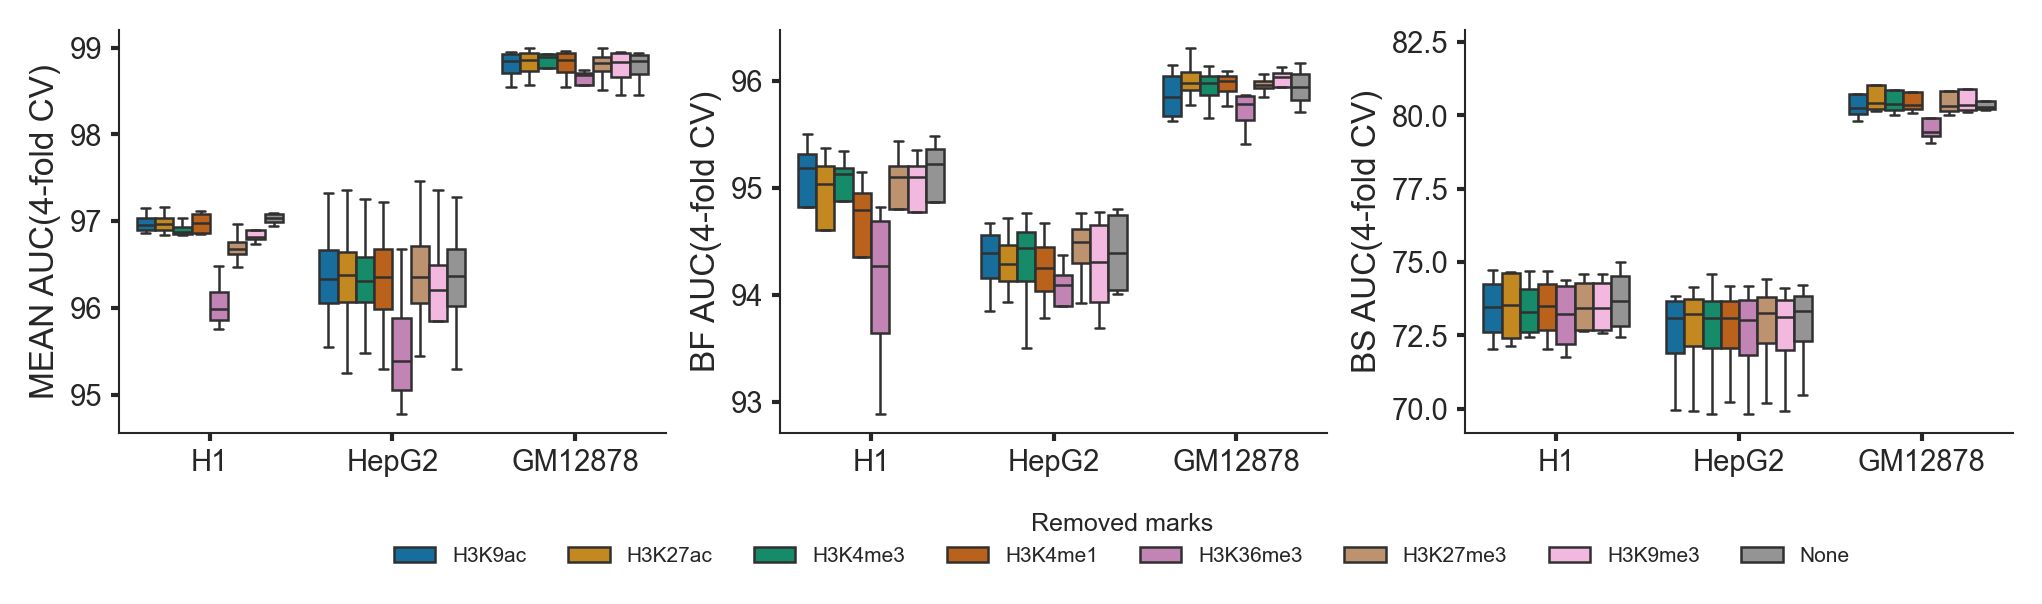

In [4]:
fig, ax = plt.subplots(1,3,constrained_layout=True,figsize=(17/2.54, 4/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = pd.Index(["remove_H3K9ac","remove_H3K27ac","remove_H3K4me3","remove_H3K4me1","remove_H3K36me3","remove_H3K27me3","remove_H3K9me3","all_marks"],name='marks')


sns.boxplot(data=ablation_mean,y='auc',x='eid',hue='remove_mark',fliersize=0,linewidth=0.6,ax=ax[0],order=order,hue_order=hue_order)
ax[0].legend().remove()  # Moves the legend outside the plot
ax[0].set_ylabel('MEAN AUC(4-fold CV)')
ax[0].set_xlabel('')

sns.boxplot(data=ablations,y='bf_auc',x='eid',hue='remove_mark',fliersize=0,linewidth=0.6,ax=ax[1],order=order)
ax[1].legend().remove()  # Moves the legend outside the plot
ax[1].set_ylabel('BF AUC(4-fold CV)')
ax[1].set_xlabel('')
sns.boxplot(data=ablations,y='bs_auc',x='eid',hue='remove_mark',fliersize=0,linewidth=0.6,ax=ax[2],order=order)
ax[2].legend().remove()  # Moves the legend outside the plot
ax[2].set_ylabel('BS AUC(4-fold CV)')
ax[2].set_xlabel('')

handles, labels = ax[0].get_legend_handles_labels()
# ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac","None"]
labels = ["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3","None"]
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, -0.01) , title='Removed marks', title_fontsize=6,fontsize=5,ncol=8,edgecolor='none')

ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[2].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
# fig.supxlabel('EID')
# plt.legend().remove()
plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure3G.eps', format='eps', bbox_inches='tight')

plt.show()

## H3K36me4 signal strength

### BS 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


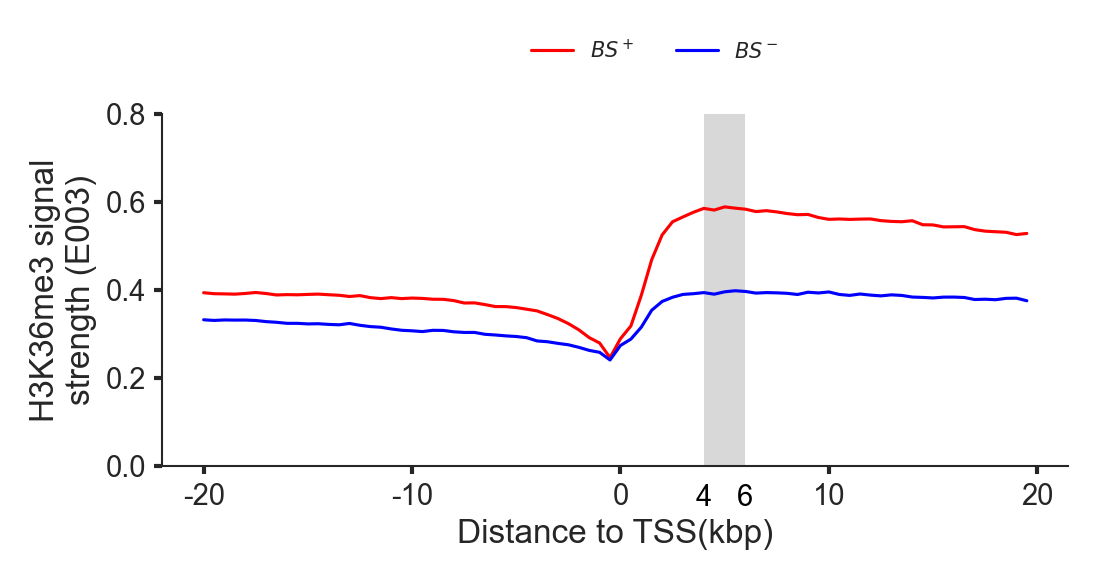

In [145]:
from matplotlib.patches import Rectangle
high_marks = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_highmarks.npy")
low_marks = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_lowmarks.npy")
idx = 4
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']

fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(9/2.54,4/2.54))


ax = sns.lineplot(high_marks[idx], color='red', label='$BS^+$')
ax = sns.lineplot(low_marks[idx], color='blue', label='$BS^-$')
ax.set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])

x_start = 4
x_end = 6
start_index = 2 * x_start + 40
end_index = 2 * x_end + 40
# Draw the rectangle between the 5-10 region in data space
rect = Rectangle((start_index, 0), end_index - start_index, 
                 1, 
                 linewidth=0, edgecolor='black', facecolor='gray', alpha=0.3)

ax.add_patch(rect)

#  Mark the x-axis ticks for 4 and 6
x_ticks_positions = [4, 6]
for x_tick in x_ticks_positions:
    tick_position = 2*x_tick + 40  # Reverse the label transformation
    # ax.scatter(tick_position, 0, color='black', zorder=5)  # Add a black dot marker
    ax.text(tick_position, -0.09, f'{x_tick}', color='black', ha='center', fontsize=7)  # Label the tick


handles, labels = ax.get_legend_handles_labels()
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
ax.legend().remove()  # Moves the legend outside the plot
fig.legend(handles, labels,  loc='upper center', bbox_to_anchor=(0.6, 1.15), fontsize=5,ncol=3,edgecolor='none')

plt.yticks([i * 0.1 for i in range(0, 10, 2)])
# Show the plot

plt.ylabel(f"{MARKS[idx]} signal\nstrength ({eid})")
plt.xlabel(f"Distance to TSS(kbp)")
plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure4D_H1.eps', format='eps', bbox_inches='tight')

plt.show()

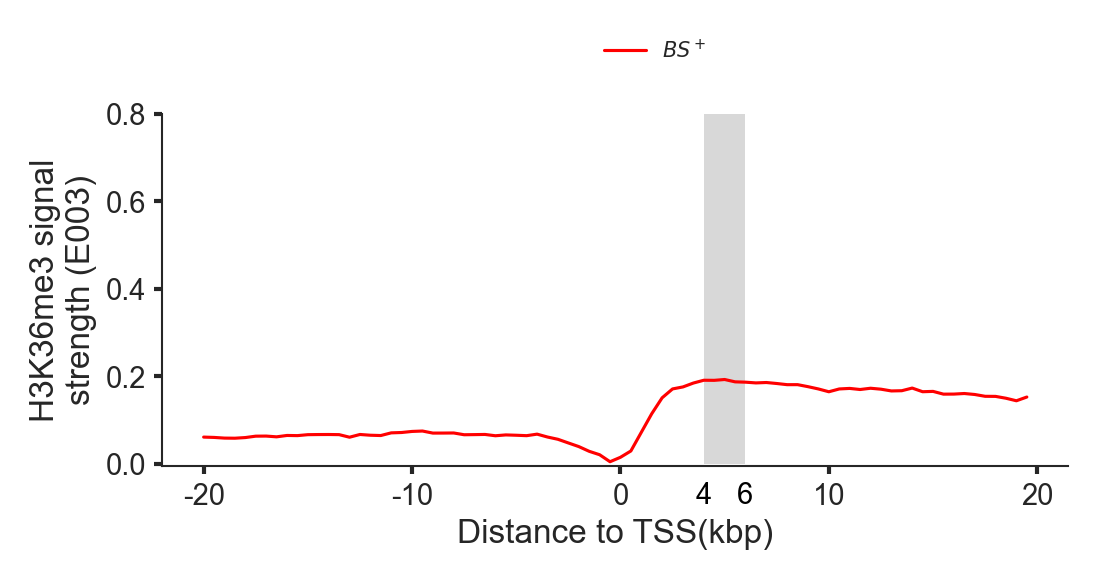

In [155]:
from matplotlib.patches import Rectangle
high_marks = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_highmarks.npy")
low_marks = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bs_lowmarks.npy")
idx = 4
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']

fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(9/2.54,4/2.54))

signal_diff = high_marks[idx] - low_marks[idx]
ax = sns.lineplot(signal_diff, color='red', label='$BS^+$')
ax.set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])

x_start = 4
x_end = 6
start_index = 2 * x_start + 40
end_index = 2 * x_end + 40
# Draw the rectangle between the 5-10 region in data space
rect = Rectangle((start_index, 0), end_index - start_index, 
                 1, 
                 linewidth=0, edgecolor='black', facecolor='gray', alpha=0.3)

ax.add_patch(rect)

#  Mark the x-axis ticks for 4 and 6
x_ticks_positions = [4, 6]
for x_tick in x_ticks_positions:
    tick_position = 2*x_tick + 40  # Reverse the label transformation
    # ax.scatter(tick_position, 0, color='black', zorder=5)  # Add a black dot marker
    ax.text(tick_position, -0.09, f'{x_tick}', color='black', ha='center', fontsize=7)  # Label the tick


handles, labels = ax.get_legend_handles_labels()
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
ax.legend().remove()  # Moves the legend outside the plot
fig.legend(handles, labels,  loc='upper center', bbox_to_anchor=(0.6, 1.15), fontsize=5,ncol=3,edgecolor='none')

plt.yticks([i * 0.1 for i in range(0, 10, 2)])
# Show the plot

plt.ylabel(f"{MARKS[idx]} signal\nstrength ({eid})")
plt.xlabel(f"Distance to TSS(kbp)")
# plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure4D_H1.eps', format='eps', bbox_inches='tight')

plt.show()

### BF

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


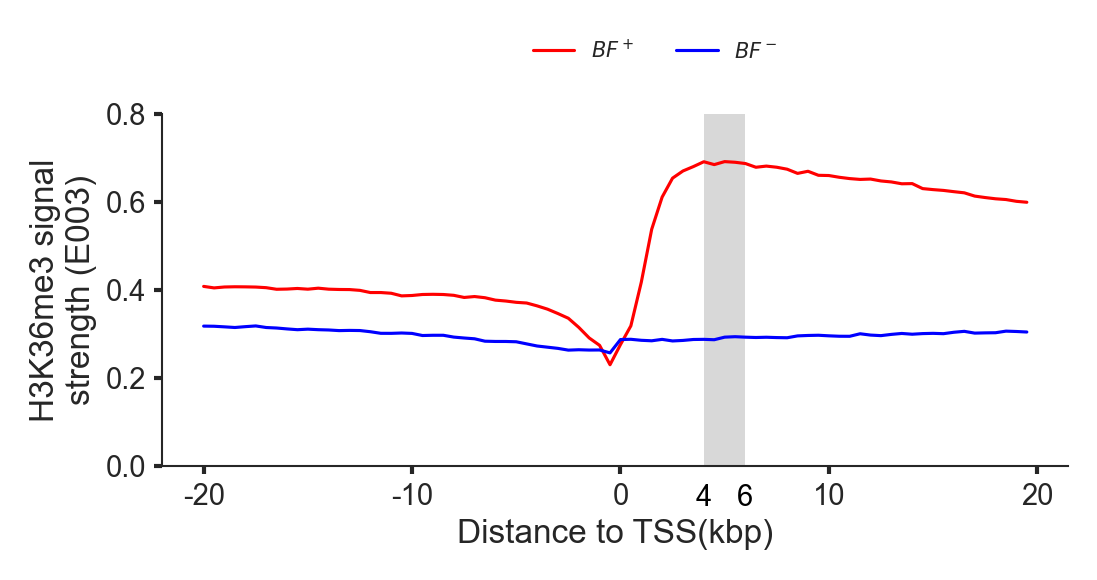

In [146]:
high_marks = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bf_highmarks.npy")
low_marks = np.load(f"extra/datasets/benchmark/Promoterformer/results/{eid}_bf_lowmarks.npy")
idx = 4
MARKS = ['H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K27me3', 'H3K36me3', 'H3K27ac', 'H3K9ac']

fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(9/2.54,4/2.54))

ax = sns.lineplot(high_marks[idx], color='red', label='$BF^+$')
ax = sns.lineplot(low_marks[idx], color='blue', label='$BF^-$')
ax.set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])


x_start = 4
x_end = 6
start_index = 2 * x_start + 40
end_index = 2 * x_end + 40
# Draw the rectangle between the 5-10 region in data space
rect = Rectangle((start_index, 0), end_index - start_index, 
                 1, 
                 linewidth=0, edgecolor='black', facecolor='gray', alpha=0.3)

ax.add_patch(rect)
#  Mark the x-axis ticks for 4 and 6
x_ticks_positions = [4, 6]
for x_tick in x_ticks_positions:
    tick_position = 2*x_tick + 40  # Reverse the label transformation
    # ax.scatter(tick_position, 0, color='black', zorder=5)  # Add a black dot marker
    ax.text(tick_position, -0.09, f'{x_tick}', color='black', ha='center', fontsize=7)  # Label the tick

handles, labels = ax.get_legend_handles_labels()
# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
ax.legend().remove()  # Moves the legend outside the plot
fig.legend(handles, labels,  loc='upper center', bbox_to_anchor=(0.6, 1.15), fontsize=5,ncol=3,edgecolor='none')

plt.yticks([i * 0.1 for i in range(0, 10,2)])
# Show the plot

plt.ylabel(f"{MARKS[idx]} signal\nstrength ({eid})")
plt.xlabel(f"Distance to TSS(kbp)")
plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure4E_H1.eps', format='eps', bbox_inches='tight')

plt.show()

## Attention Analysis

### Load Models with H3K36me3

In [157]:
import argparse
import torch
import torch.nn as nn
import os
import pandas as pd
import yaml
import numpy as np
from tqdm import tqdm
from typing import List
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from benchmark.Promoterformer.data import BurstformerDataset
from benchmark.Promoterformer.net import  ChromoformerClassifier
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from benchmark.Promoterformer.constants import get_config
from src.utils.visualization import plot_heatmap


torch.autograd.set_detect_anomaly(True)


def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

#
# Training setup.
#
config_path = "benchmark/Promoterformer/configs/default.yaml"
config = get_config(config_path)
# add_feature_bin = True
add_feature_bin = False

eid = 'E003'
remove_marks = None

if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []

feature_bin_kws = config['feature_bin_kws']
seed = config["seed"]

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])  + feature_bin_kws['out_channels'] if add_feature_bin else config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
# targets = ['bs_label','bf_label']
targets = ['mean_label']
npy_dir = "extra/datasets/processed/v1"

models = {}
datasets = {}
for fold in [0,1,2,3]:

    binsizes = [500]
    checkpoints = f"benchmark/Promoterformer/checkpoints/{eid}.{fold}.No_feature_bin.mean.model.pt"
    
    meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"

    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    # Split genes into two sets (train/val).
    genes = set(meta.gene_id.unique())
    n_genes = len(genes)
    print("Target genes:", len(genes))
    print(f"n_feats_p:{n_feats_p}")

    splits = {
        1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
        2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
        3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
        4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
    }

    chromosome_splits = {}
    for key, chroms in splits.items():
        for chrom in chroms:
            chromosome_splits[chrom] = key

    qs = [
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
    ]

    train_genes = (
        qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
    )
    val_genes = qs[(fold + 3) % 4]



    print(len(train_genes), len(val_genes))

    val_dataset = BurstformerDataset(
        meta_path,
        npy_dir,
        val_genes,
        i_max,
        binsizes,
        w_prom,
        w_max,
        config = config,
        with_gene_id=True
    )
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz, num_workers=8)

    model = ChromoformerClassifier(
        n_feats_p,
        n_feats_pcres,
        d_emb,
        d_head,
        feature_bin_kws=feature_bin_kws,
        embed_kws=embed_kws,
        binsizes=binsizes,
        seed=42,
        targets=targets,
        add_feature_bin = add_feature_bin,
    ).to(DEVICE)

    ckpt = torch.load(checkpoints,map_location=DEVICE)
    model.load_state_dict(ckpt["net"])
    models[fold] = model 
    datasets[fold] = val_dataset

Target genes: 14304
n_feats_p:7
10819 3485
Target genes: 14304
n_feats_p:7
10449 3855
Target genes: 14304
n_feats_p:7
10790 3514
Target genes: 14304
n_feats_p:7
10854 3450


### Load Models removed H3K36me3

In [158]:
import argparse
import torch
import torch.nn as nn
import os
import pandas as pd
import yaml
import numpy as np
from tqdm import tqdm
from typing import List
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from benchmark.Promoterformer.data import BurstformerDataset
from benchmark.Promoterformer.net import  ChromoformerClassifier
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from benchmark.Promoterformer.constants import get_config
from src.utils.visualization import plot_heatmap


torch.autograd.set_detect_anomaly(True)


def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

#
# Training setup.
#
config_path = "benchmark/Promoterformer/configs/default.yaml"
config = get_config(config_path)
# add_feature_bin = True
add_feature_bin = False

eid = 'E003'
remove_marks = "H3K36me3"

if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []

feature_bin_kws = config['feature_bin_kws']
seed = config["seed"]

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])  + feature_bin_kws['out_channels'] if add_feature_bin else config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
# targets = ['bs_label','bf_label']
targets = ['mean_label']
npy_dir = "extra/datasets/processed/v1"

models_without_h3k36me3 = {}
datasets_without_h3k36me3 = {}
for fold in [0,1,2,3]:

    binsizes = [500]
    checkpoints = f"benchmark/Promoterformer/checkpoints/{eid}.remove_{remove_marks}.{fold}.No_feature_bin.mean.model.pt"
    meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"

    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    # Split genes into two sets (train/val).
    genes = set(meta.gene_id.unique())
    n_genes = len(genes)
    print("Target genes:", len(genes))
    print(f"n_feats_p:{n_feats_p}")

    splits = {
        1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
        2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
        3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
        4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
    }

    chromosome_splits = {}
    for key, chroms in splits.items():
        for chrom in chroms:
            chromosome_splits[chrom] = key

    qs = [
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
    ]

    train_genes = (
        qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
    )
    val_genes = qs[(fold + 3) % 4]



    print(len(train_genes), len(val_genes))

    val_dataset = BurstformerDataset(
        meta_path,
        npy_dir,
        val_genes,
        i_max,
        binsizes,
        w_prom,
        w_max,
        config = config,
        with_gene_id=True
    )
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz, num_workers=8)

    model = ChromoformerClassifier(
        n_feats_p,
        n_feats_pcres,
        d_emb,
        d_head,
        feature_bin_kws=feature_bin_kws,
        embed_kws=embed_kws,
        binsizes=binsizes,
        seed=42,
        targets=targets,
        add_feature_bin = add_feature_bin,
    ).to(DEVICE)

    ckpt = torch.load(checkpoints,map_location=DEVICE)
    model.load_state_dict(ckpt["net"])
    models_without_h3k36me3[fold] = model 
    datasets_without_h3k36me3[fold] = val_dataset

Target genes: 14304
n_feats_p:6
10819 3485
Target genes: 14304
n_feats_p:6
10449 3855
Target genes: 14304
n_feats_p:6
10790 3514
Target genes: 14304
n_feats_p:6
10854 3450


### Analysis attention regions

In [159]:
def get_attention_weights(gene_id, dataset, model,binsize=500,dims=None):
    sample = dataset.get_sample(gene_id, add_bsz_dim=True)

    x = sample["promoter_feats"][binsize]
    mask = sample["promoter_pad_masks"][binsize]

    if model.feature_bin:
        layer = model.feature_bin[str(binsize)]
        feat_emb = layer(sample["promoter_seq"])
        x = torch.cat([x,feat_emb],dim=-1)

    x, mask = model.generate_transformer_inputs(x, mask, binsize)
    attention_weights = np.squeeze(model.get_attention_weights(binsize,x,mask))
    if isinstance(dims,int):
        attention_weights = attention_weights[dims]
    else:
        attention_weights = np.sum(attention_weights, axis=0)
    return attention_weights

def extract_attention_regions(weights, chrom, center, strand, threshold=0.05, bin_size=500)->List[str]:
    if strand == '-':
        weights = np.flip(weights)

    def _distance_to_tss(location):
        return bin_size*(location-40)  # 第40个bin 以TSS 作为起点所在bin

    regions = []
    region = []
    for idx, weight in enumerate(weights):
        if weight > threshold:
            region.append(idx)
        else:
            if region:
                regions.append(region)
                region = []
    if region:
        regions.append(region)
    
    genomic_regions = []
    for region in regions:
        start = center + _distance_to_tss(region[0])
        end =  center + _distance_to_tss(region[-1]+1)
        genomic_regions.append(f"{chrom}:{start}-{end}")

    return genomic_regions

In [161]:
LABEL_BIN_MAP = {
    "Low bs and low bf":"C1",
    "High bs and low bf":"C2",
    "Low bs and high bf":"C3",
    "High bs and high bf":"C4",
}
data = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{eid}_results.csv')
data = pd.merge(data,meta[['gene_id','chrom','start','strand']],how='inner',on='gene_id')
data
dims = None

### ALL datasets

100%|██████████| 14304/14304 [02:52<00:00, 82.76it/s]


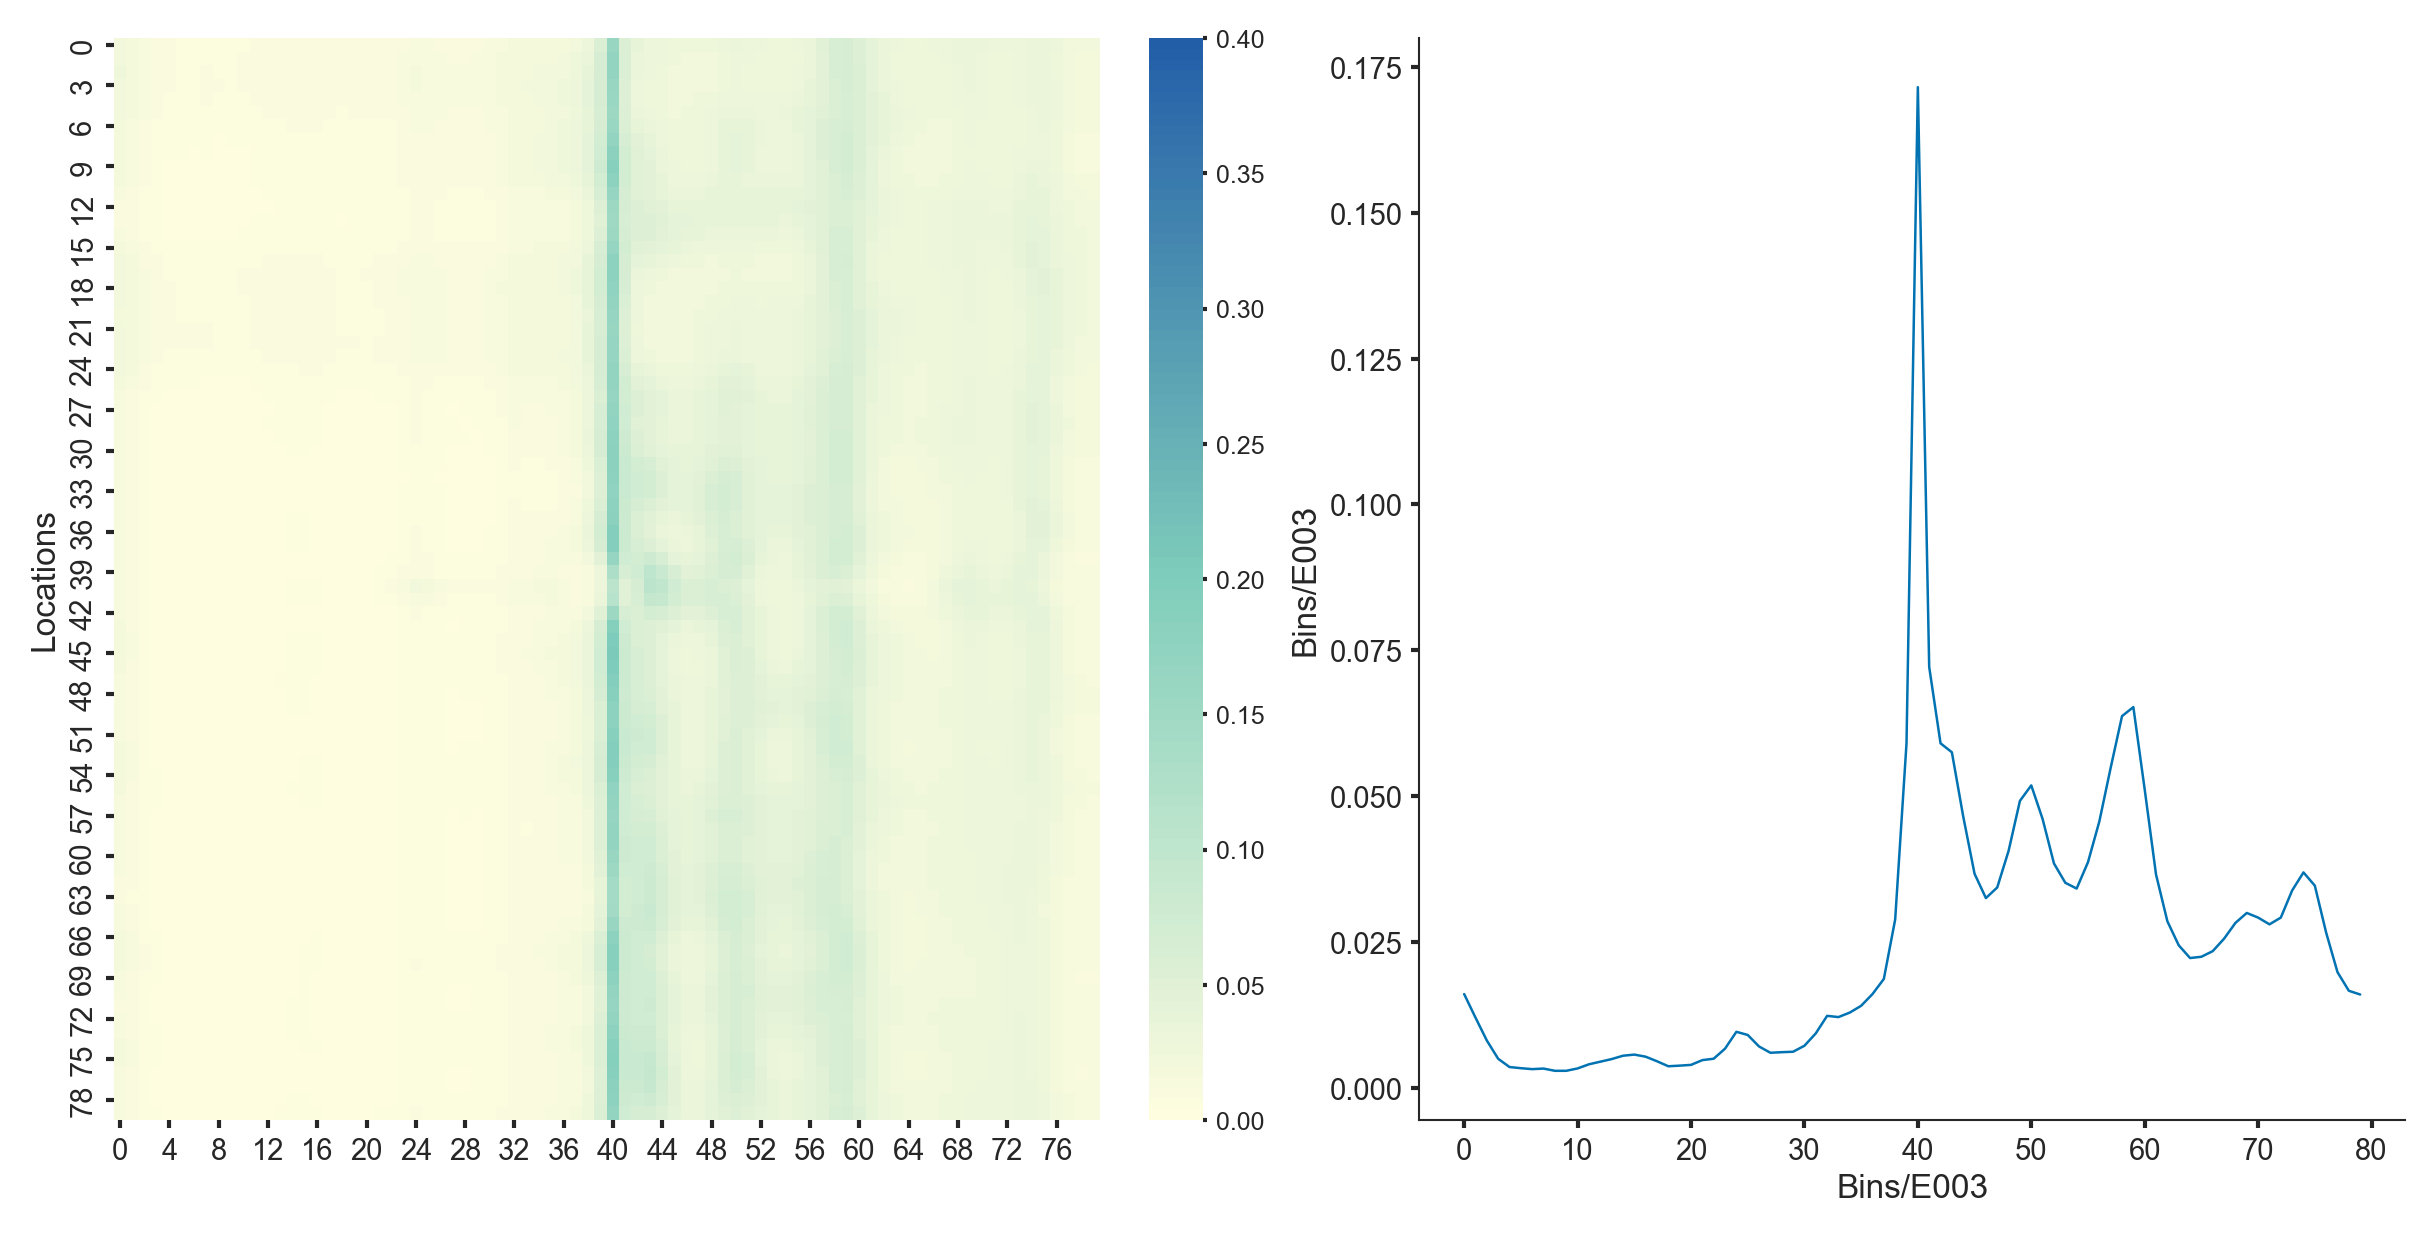

In [162]:
high_gene_ids = data

attention_weights = 0
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets[fold], models[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(high_gene_ids)

# with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_attention_weights_with_h3k36me3.npy','wb') as w:
#     np.save(w,attention_weights)

attention_distribution = np.mean(attention_weights, axis=0)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(8, 4))

plot_heatmap(attention_weights,axis=ax[0])
plt.plot(attention_distribution,lw=0.6, label='Feature Importance')

plt.xlabel(f"Bins/{eid}")
plt.ylabel(f"Bins/{eid}")

plt.show()



In [163]:
high_gene_ids = data

attention_weights = 0
for record in tqdm(high_gene_ids.to_records()):
    gene_id = record['gene_id']
    fold = record['fold']
    attention_weights += get_attention_weights(gene_id, datasets_without_h3k36me3[fold], models_without_h3k36me3[fold], binsize=binsizes[0],dims=dims)

attention_weights = attention_weights/len(high_gene_ids)

# with open(f'extra/datasets/benchmark/Promoterformer/results/{eid}_attention_weights_remove_h3k36me3.npy','wb') as w:
#     np.save(w,attention_weights)



100%|██████████| 14304/14304 [02:42<00:00, 87.77it/s]


In [16]:
def normalized_kde(data) : 
    g = sns.lineplot( data,)
    plt.close('all')
    
    line = g.get_lines()[0]
    xd = line.get_xdata()
    yd = line.get_ydata()
    # https://stackoverflow.com/questions/29661574/normalize-numpy-array-columns-in-python

    #normalize points
    yd2 = (yd - yd.min(0)) / yd.ptp(0)
    # plot them in another graph
    return (xd, yd2)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


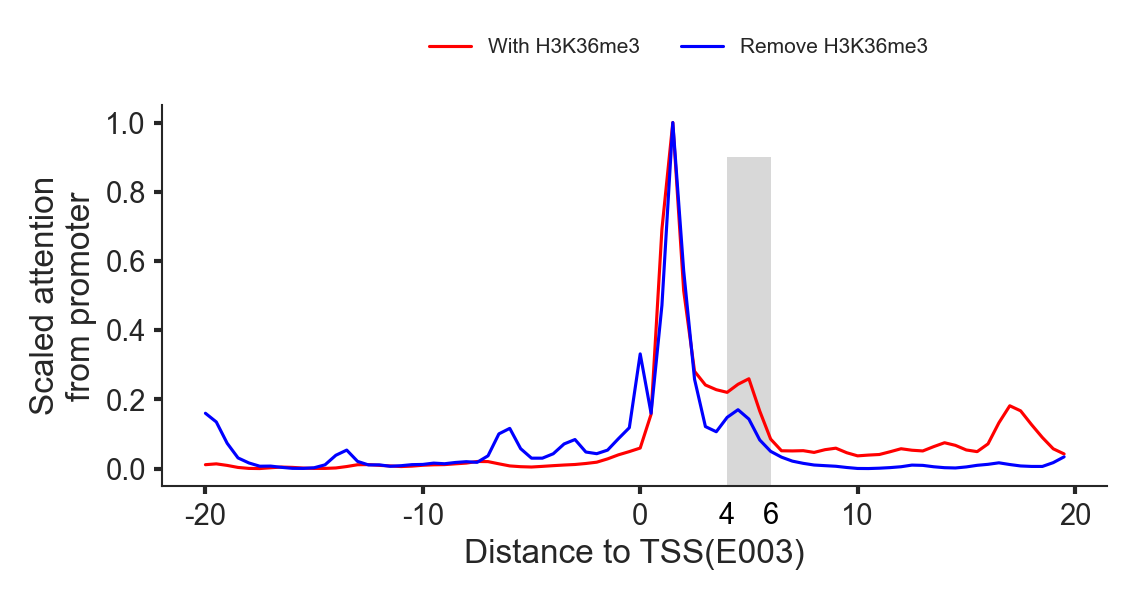

In [149]:
eid='E003'
attention_weights_with_h3k36me3 = np.load(f'extra/datasets/benchmark/Promoterformer/results/{eid}_attention_weights_with_h3k36me3.npy')
# attention_distribution_with_h3k36me3 = np.mean(attention_weights_with_h3k36me3, axis=0)
attention_distribution_with_h3k36me3 = attention_weights_with_h3k36me3[40]

attention_weights_remove_h3k36me3 = np.load(f'extra/datasets/benchmark/Promoterformer/results/{eid}_attention_weights_remove_h3k36me3.npy')
# attention_distribution_remove_h3k36me3 = np.mean(attention_weights_remove_h3k36me3, axis=0)
attention_distribution_remove_h3k36me3 = attention_weights_remove_h3k36me3[40]
x_with_h3k36me3, y_with_h3k36me3 = normalized_kde(attention_distribution_with_h3k36me3)
x_remove_h3k36me3, y_remove_h3k36me3 = normalized_kde(attention_distribution_remove_h3k36me3)

fig, ax =plt.subplots(1,1,constrained_layout=True, figsize=(9/2.54, 4/2.54))

# plot_heatmap(attention_weights,axis=ax[0])
g = sns.lineplot(x=x_with_h3k36me3,y=y_with_h3k36me3,color='red',label="With H3K36me3")
# g.fill_between(x_with_h3k36me3, 0, y_with_h3k36me3 ,color='red' ,alpha=0.5,label="With H3K36me3")

g = sns.lineplot(x=x_remove_h3k36me3,y=y_remove_h3k36me3,color='blue',label="Remove H3K36me3")
# g.fill_between(x_remove_h3k36me3, 0, y_remove_h3k36me3 ,color='blue' ,alpha=0.5,label="Remove H3K36me3")
g.set_xticks([i for i in range(0, 81, 20)],labels=[int((i-40)/2) for i in range(0, 81, 20)])
g.set_xlabel(f"Distance to TSS({eid})")
g.set_ylabel("Scaled attention\nfrom promoter")


x_start = 4
x_end = 6
start_index = 2 * x_start + 40
end_index = 2 * x_end + 40
# Draw the rectangle between the 5-10 region in data space
rect = Rectangle((start_index, -0.1), end_index - start_index, 
                 1, 
                 linewidth=0, edgecolor='black', facecolor='gray', alpha=0.3)

ax.add_patch(rect)

#  Mark the x-axis ticks for 4 and 6
x_ticks_positions = [4, 6]
for x_tick in x_ticks_positions:
    tick_position = 2*x_tick + 40  # Reverse the label transformation
    # ax.scatter(tick_position, 0, color='black', zorder=5)  # Add a black dot marker
    g.text(tick_position, -0.16, f'{x_tick}', color='black', ha='center', fontsize=7)  # Label the tick


handles, labels = g.get_legend_handles_labels()
g.legend().remove()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.6, 1.15), fontsize=5,ncol=3,edgecolor='none')
plt.savefig('extra/datasets/benchmark/Promoterformer/figures/Figure4F_H1.eps', format='eps', bbox_inches='tight')

plt.show()
